# **Задание 5.** CLIP

## Импорт библиотек и модулей

In [77]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import random
import cv2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from typing import Optional, Callable

from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import accuracy_score as acc, precision_score as P, recall_score as R, confusion_matrix as cm, classification_report as report
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torchvision as tv
import torchvision.transforms.v2 as T
import albumentations as A
from transformers import CLIPModel, CLIPProcessor

import kagglehub as kaggle
import datasets as ds

Зададим значение `seed` и зафиксируем его:

In [78]:
seed_value = 927

random.seed(seed_value)
torch.manual_seed(seed_value)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [79]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.mps.is_available() else
    "cpu"
)
print(f"Using device: {device}")

Using device: mps


## Загрузка датасета

In [80]:
data_path = kaggle.dataset_download("cashbowman/ai-generated-images-vs-real-images")
print(f"Path to the dataset: {data_path}")

Path to the dataset: /Users/dji/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1


## Реализация датасета

In [81]:
class CustomDataset(Dataset):
    def __init__(
        self,
        data_path: str,
        processor: CLIPProcessor,
        train: bool = True,
        transform: Optional[Callable] = None
    ):
        self.data_path = data_path
        self.realart_path = os.path.join(self.data_path, "RealArt", "RealArt")
        self.aiart_path = os.path.join(self.data_path, "AiArtData", "AiArtData")

        all_imgs = dict()
        for path, label in zip([self.realart_path, self.aiart_path],
                               [0, 1]):
            imgs = os.listdir(path)
            for img in imgs:
                all_imgs[os.path.join(path, img)] = label

        paths, labels = list(all_imgs.keys()), list(all_imgs.values())
        t_paths, v_paths, t_labels, v_labels = tts(
            paths, labels,
            test_size=0.2,
            random_state=seed_value,
            stratify=labels
        )

        self.train = train
        if train:
            self.paths, self.labels = t_paths, t_labels
        else:
            self.paths, self.labels = v_paths, v_labels

        self.transform = transform
        self.processor = processor  # CLIPProcessor

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path, label = self.paths[idx], self.labels[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform and self.train:
            tfm = self.transform(image=img)
            img = tfm['image']

        # needed instead of ToTensorV2
        pixel_values = self.processor(img, return_tensors="pt")["pixel_values"][0]

        return pixel_values, torch.tensor(label, dtype=torch.long)

## Задание аугментаций

In [82]:
def get_transform(train: bool = True):
    if train:
        return A.Compose([
            A.Resize(224, 224),
            A.RandomBrightnessContrast(
                brightness_limit=0.2,
                contrast_limit=0.2,
                p=0.5
            ),
            A.OneOf([
                A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=0.5),
                A.Blur(blur_limit=3, p=0.3),
                A.GaussianBlur(blur_limit=(3, 5), sigma_limit=0.5, p=0.3),
            ], p=0.6),
            A.OneOf([
                A.GaussNoise(p=0.5),
                A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=0.5),
            ], p=0.5),
            A.HueSaturationValue(
                hue_shift_limit=10,
                sat_shift_limit=20,
                val_shift_limit=15,
                p=0.4
            ),
            A.ShiftScaleRotate(
                shift_limit=0.05,
                scale_limit=0.05,
                rotate_limit=5,
                border_mode=cv2.BORDER_REFLECT,
                p=0.4
            ),
            A.Emboss(alpha=(0.2, 0.5), strength=(0.2, 0.7), p=0.2),
        ])
    else:
        return A.Resize(224, 224)

## Реализация функции создания даталоадера

In [83]:
def create_custom_dl(
    data_path: str,
    processor: CLIPProcessor,
    train: bool = True
):
    ds = CustomDataset(
        data_path=data_path,
        processor=processor,
        train=train,
        transform=get_transform(train=train)
    )
    dl = DataLoader(
        dataset=ds,
        batch_size=32,
        shuffle=(True if train else False),
        num_workers=0
    )
    return dl

## Zero-shot

In [84]:
pretrained_type = "openai/clip-vit-base-patch32"

In [85]:
model = CLIPModel.from_pretrained(pretrained_type)

In [86]:
model = model.to(device)

In [87]:
processor = CLIPProcessor.from_pretrained(pretrained_type)

In [88]:
class_prompts = {
    "ai": ["an image generated with AI"],
    "real": ["a real picture", "a real photo"]
}

prompt_pairs = [
    (cls_name, prompt)
    for cls_name, prompts in class_prompts.items()
    for prompt in prompts
]
class_names, prompts = zip(*prompt_pairs) if prompt_pairs else ([], [])
text_inputs = processor(
    text=prompts,
    return_tensors="pt",
    padding=True
).to(device)

with torch.no_grad():
    text_features = model.get_text_features(**text_inputs)
    text_features /= text_features.norm(dim=-1, keepdim=True)

In [89]:
def zero_shot_predict(dataloader):
    if not hasattr(zero_shot_predict, 'prompt_weights'):
        class_order = list(class_prompts.keys())
        prompt_weights = torch.zeros(len(class_names), len(class_order), device=device)
        for i, cls in enumerate(class_names):
            cls_idx = class_order.index(cls)
            prompt_weights[i, cls_idx] = 1 / len(class_prompts[cls])
        zero_shot_predict.prompt_weights = prompt_weights

    all_preds, all_probs, all_labels = [], [], []

    for images, labels in tqdm(dataloader, desc="Zero-shot"):
        images = images.to(device)
        with torch.no_grad():
            img_features = model.get_image_features(images)
            img_features /= img_features.norm(dim=-1, keepdim=True)

            logits = (100.0 * img_features @ text_features.T) @ zero_shot_predict.prompt_weights
            
            probabilities = torch.softmax(logits, dim=1)
            predictions = probabilities.argmax(dim=1)

        all_preds.extend(predictions.cpu().numpy())
        all_probs.extend(probabilities.cpu().numpy())
        all_labels.extend(labels.numpy())

    return all_preds, all_probs, all_labels

In [90]:
train_dl = create_custom_dl(data_path=data_path, processor=processor, train=True)
val_dl = create_custom_dl(data_path=data_path, processor=processor, train=False)

/opt/homebrew/anaconda3/envs/nn-arch-venv/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### Оценка zero-shot на трейне

In [91]:
zeroshot_preds_train, zeroshot_probs_train, zeroshot_labels_train = zero_shot_predict(train_dl)

Zero-shot: 100%|██████████| 25/25 [00:14<00:00,  1.70it/s]


In [92]:
def metrics_report(gt, pred, class_names: Optional[list] = ["RealArt", "AiArtData"], verbose: bool = True):
    accuracy = acc(gt, pred)
    precision = P(gt, pred, average="weighted")
    recall = R(gt, pred, average="weighted")

    classification_report = report(gt, pred, target_names=class_names)

    confusion_matrix = cm(gt, pred)
    if verbose:
        print(f"Accuracy: {round(accuracy, 3)}, \nPrecision: {round(precision, 3)}, \nRecall: {round(recall, 3)}.")
        print(f"Classification report: \n{classification_report}")
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            confusion_matrix, 
            annot=True, 
            fmt='d', 
            cmap='Reds',
            xticklabels=class_names,
            yticklabels=class_names
        )
        plt.title("Confusion Matrix")
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()
    else:
        return accuracy, precision, recall, classification_report, confusion_matrix

Accuracy: 0.418, 
Precision: 0.386, 
Recall: 0.418.
Classification report: 
              precision    recall  f1-score   support

     RealArt       0.43      0.85      0.57       349
   AiArtData       0.35      0.06      0.11       431

    accuracy                           0.42       780
   macro avg       0.39      0.46      0.34       780
weighted avg       0.39      0.42      0.31       780



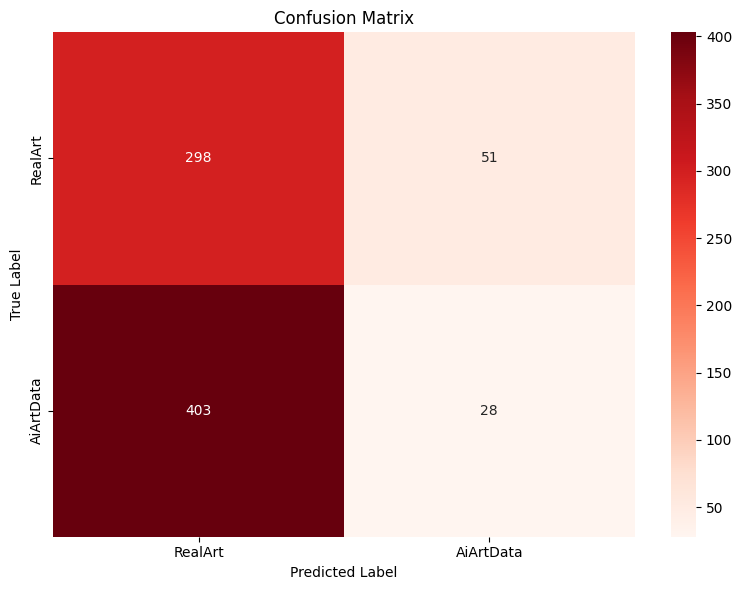

In [93]:
metrics_report(gt=zeroshot_labels_train, pred=zeroshot_preds_train, verbose=True)

### Оценка zero-shot на валидации

In [94]:
zeroshot_preds_val, zeroshot_probs_val, zeroshot_labels_val = zero_shot_predict(val_dl)

Zero-shot: 100%|██████████| 7/7 [00:04<00:00,  1.59it/s]


Accuracy: 0.379, 
Precision: 0.388, 
Recall: 0.379.
Classification report: 
              precision    recall  f1-score   support

     RealArt       0.37      0.53      0.43        87
   AiArtData       0.41      0.26      0.32       108

    accuracy                           0.38       195
   macro avg       0.39      0.39      0.37       195
weighted avg       0.39      0.38      0.37       195



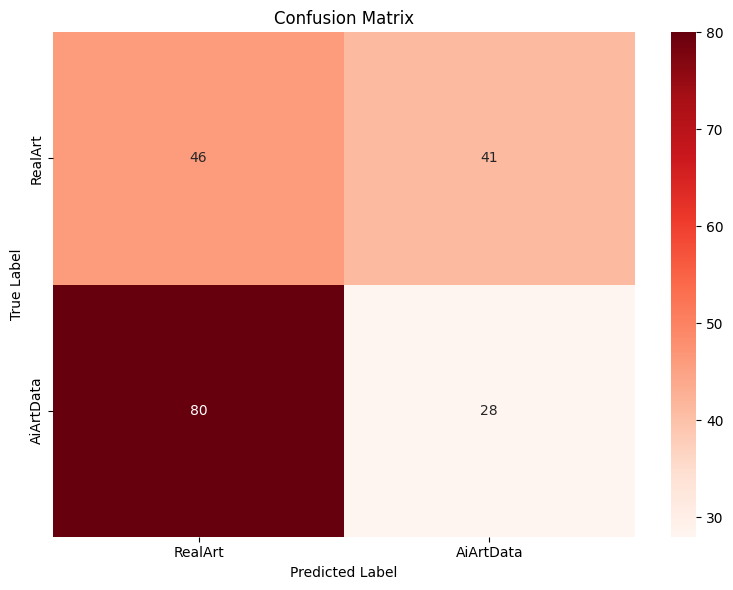

In [95]:
metrics_report(gt=zeroshot_labels_val, pred=zeroshot_preds_val, verbose=True)

## Fine-Tuning модели

In [96]:
class CLIPFT(nn.Module):
    def __init__(self, zero_shot_model):
        super().__init__()
        self.zeroshot = zero_shot_model
        hidden = self.zeroshot.vision_model.config.hidden_size
        self.fc = nn.Sequential(
            nn.Linear(hidden, 512),
            nn.Dropout(0.3),
            nn.LeakyReLU(),
            nn.Linear(512, 256),
            nn.Dropout(0.3),
            nn.LeakyReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, pixel_values):
        output = self.zeroshot.vision_model(pixel_values=pixel_values)
        logits = self.fc(output.pooler_output)
        return logits

In [97]:
ft_model = CLIPFT(model).to(device)

In [98]:
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    correct = 0
    total_samples = 0

    for x, y in tqdm(dataloader, desc="Training", leave=False):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        
        logits = model(x)
        loss = criterion(logits, y)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, correct / total_samples


def evaluate_model(model, dataloader, criterion=None):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, y in tqdm(dataloader, desc="Evaluation", leave=False):
            x, y = x.to(device), y.to(device)

            logits = model(x)

            if criterion:
                loss = criterion(logits, y)
                total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(dataloader) if criterion else 0

    return all_preds, all_labels, all_probs, avg_loss


def train(model, train_dataloader, val_dataloader, num_epochs=5, lr=1e-4, weight_decay=1e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    train_history = {'loss': [], 'accuracy': []}
    val_history = {'loss': [], 'accuracy': []}
    val_best = 0
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}/{num_epochs}:")

        train_loss, train_acc = train_epoch(model, train_dataloader, optimizer, criterion)
        train_history['loss'].append(train_loss)
        train_history['accuracy'].append(train_acc)

        val_preds, val_labels, _, val_loss = evaluate_model(model, val_dataloader, criterion)
        val_acc = acc(val_labels, val_preds)
        if val_acc > val_best:
            torch.save(ft_model.state_dict(), "best.pth")
        val_history['loss'].append(val_loss)
        val_history['accuracy'].append(val_acc)

        print(f"Train Loss: {train_loss:.6f}, Train Accuracy: {train_acc:.6f}")
        print(f"Val Loss: {val_loss:.6f}, Val Accuracy: {val_acc:.6f}")

    return train_history, val_history

In [99]:
ft_train_hist, ft_val_hist = train(
    model=ft_model,
    train_dataloader=train_dl,
    val_dataloader=val_dl,
    lr=1e-5,
    weight_decay=1e-2
)

Epoch 0/5:


Training:  92%|█████████▏| 23/25 [00:36<00:03,  1.59s/it]libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


Train Loss: 0.654723, Train Accuracy: 0.589744
Val Loss: 0.571348, Val Accuracy: 0.758974
Epoch 1/5:


Training:  76%|███████▌  | 19/25 [00:32<00:08,  1.46s/it]libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


Train Loss: 0.524533, Train Accuracy: 0.793590
Val Loss: 0.421183, Val Accuracy: 0.861538
Epoch 2/5:


...

Train Loss: 0.410384, Train Accuracy: 0.860256
Val Loss: 0.355879, Val Accuracy: 0.866667
Epoch 3/5:


Training:  76%|███████▌  | 19/25 [00:37<00:10,  1.79s/it]libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


Train Loss: 0.325359, Train Accuracy: 0.892308
Val Loss: 0.339799, Val Accuracy: 0.871795
Epoch 4/5:


Training:  92%|█████████▏| 23/25 [00:37<00:02,  1.36s/it]libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


Train Loss: 0.288314, Train Accuracy: 0.905128
Val Loss: 0.321610, Val Accuracy: 0.871795


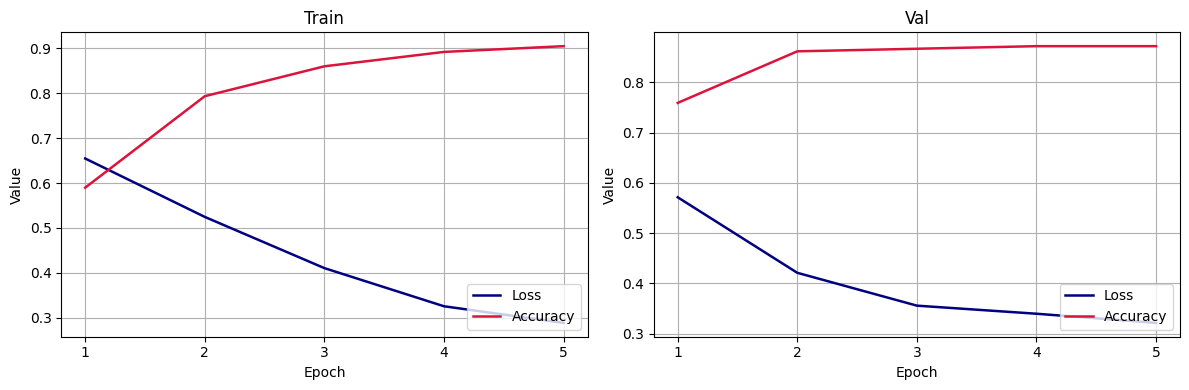

In [100]:
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(ft_train_hist['loss'], color='navy', label='Loss', lw=1.8)
plt.plot(ft_train_hist['accuracy'], color='crimson', label='Accuracy', lw=1.8)
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Train')
plt.xticks(range(0, 5), range(1, 6))
plt.grid()
plt.legend(loc='lower right')
plt.subplot(122)
plt.plot(ft_val_hist['loss'], color='navy', label='Loss', lw=1.8)
plt.plot(ft_val_hist['accuracy'], color='crimson', label='Accuracy', lw=1.8)
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Val')
plt.xticks(range(0, 5), range(1, 6))
plt.grid()
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Оценка fine-tuned

In [101]:
zeroshot_model = CLIPModel.from_pretrained(pretrained_type).to(device)
ft_model_best = CLIPFT(zeroshot_model).to(device)
ft_model_best.load_state_dict(torch.load("./best.pth"))

<All keys matched successfully>

In [102]:
ft_model_best.eval()
ft_train_pred, ft_train_true, _, _ = evaluate_model(ft_model_best, train_dl)
ft_val_pred, ft_val_true, _, _ = evaluate_model(ft_model_best, val_dl)

Evaluation:  28%|██▊       | 7/25 [00:04<00:11,  1.63it/s]libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


#### Трейн

Accuracy: 0.931, 
Precision: 0.933, 
Recall: 0.931.
Classification report: 
              precision    recall  f1-score   support

     RealArt       0.97      0.88      0.92       349
   AiArtData       0.91      0.97      0.94       431

    accuracy                           0.93       780
   macro avg       0.94      0.93      0.93       780
weighted avg       0.93      0.93      0.93       780



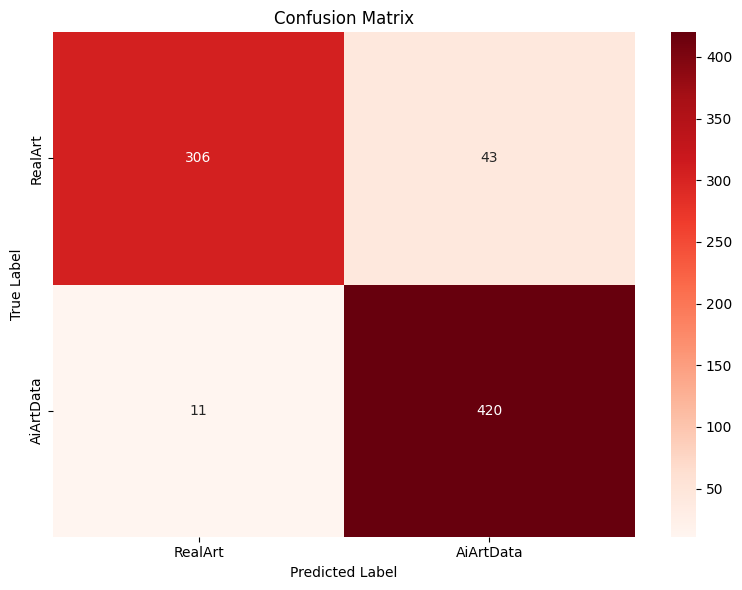

In [103]:
metrics_report(ft_train_true, ft_train_pred)

#### Валидация

Accuracy: 0.872, 
Precision: 0.873, 
Recall: 0.872.
Classification report: 
              precision    recall  f1-score   support

     RealArt       0.89      0.82      0.85        87
   AiArtData       0.86      0.92      0.89       108

    accuracy                           0.87       195
   macro avg       0.87      0.87      0.87       195
weighted avg       0.87      0.87      0.87       195



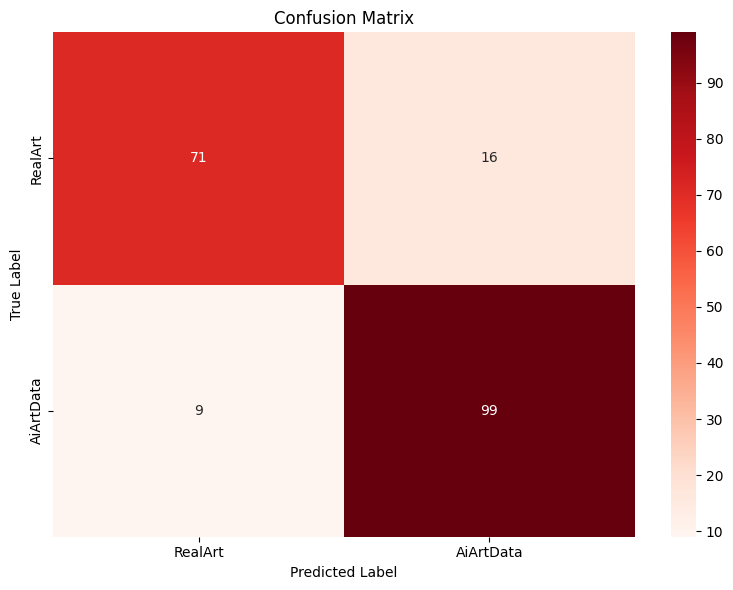

In [104]:
metrics_report(ft_val_true, ft_val_pred)

## Вывод

Модель после файн-тюнинга отработала сильно лучше, но было замечено, что она склонна к переобучению. Метрики могут быть улучшены корректировкой гиперпараметров и/или аугментаций.